In [33]:
import pandas as pd
import numpy as np


In [34]:
data = pd.read_csv('/content/Cardiotocographic.csv')

**1.	Data Cleaning and Preparation:**

●	Load the dataset into a data frame or equivalent data structure.

●	Handle missing values appropriately (e.g., imputation, deletion).

●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).

●	Detect and treat outliers if necessary.


In [35]:
data.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [36]:
data.shape

(2126, 14)

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [38]:
data.describe()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [39]:
# 2. Fix Data Types and Inconsistencies in 'NSP'
# Handle missing values in 'NSP' before rounding and converting to int
# We'll drop rows where 'NSP' is NaN to maintain consistency with the earlier data cleaning step
data.dropna(subset=['NSP'], inplace=True)
# Round NSP to nearest integer and convert to Int
data['NSP'] = data['NSP'].round().astype(int)
# Remove rows where NSP is not 1, 2, or 3
data = data[data['NSP'].isin([1, 2, 3])]

In [40]:
# identify null values
data.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [41]:
# here we drop null values
data = data.dropna()

In [42]:
# intially we have 2126 rows now we have 2095 rows. so after deleting 21 rows wont affect oue data much because it hardly more than 1%.
data.shape

(2095, 14)

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2095 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2095 non-null   float64
 1   AC        2095 non-null   float64
 2   FM        2095 non-null   float64
 3   UC        2095 non-null   float64
 4   DL        2095 non-null   float64
 5   DS        2095 non-null   float64
 6   DP        2095 non-null   float64
 7   ASTV      2095 non-null   float64
 8   MSTV      2095 non-null   float64
 9   ALTV      2095 non-null   float64
 10  MLTV      2095 non-null   float64
 11  Width     2095 non-null   float64
 12  Tendency  2095 non-null   float64
 13  NSP       2095 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 245.5 KB


In [44]:
data.isnull().sum() #CrossCheck

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [45]:
#Outlier Handle
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
#Cal Lower and Upper Whisker
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Create a new DataFrame with outliers capped at the whisker bounds
data_new = data.clip(lower=lower_whisker, upper=upper_whisker, axis=1)



In [46]:
data_new.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2095.000000,2095.000000,2095.000000,2095.000000,2095.000000,2095.0,2095.0,2095.000000,2095.000000,2095.000000,2095.000000,2095.000000,2095.000000,2095.0
mean,133.300640,0.003132,0.001557,0.004353,0.001767,0.0,0.0,47.011376,1.301729,6.722423,8.030427,70.181922,0.319321,1.0
std,9.996100,0.003837,0.002464,0.003005,0.002665,0.0,0.0,17.658136,0.780119,10.399353,5.081995,39.747501,0.625255,0.0
min,104.900596,-0.008432,-0.003821,-0.005261,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.850000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001817,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001616,0.000000,0.004478,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.066270,0.005621,0.002547,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.0
max,161.165674,0.014053,0.006368,0.013614,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.350000,194.500000,2.500000,1.0


**While doing data Preprocessing we sucessfully handle Null Values and Outiler.**

**2.	Statistical Summary:**

●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).

●	Highlight any interesting findings from this summary.


In [47]:
Mean = data_new.mean()
print(Mean)

LB          133.300640
AC            0.003132
FM            0.001557
UC            0.004353
DL            0.001767
DS            0.000000
DP            0.000000
ASTV         47.011376
MSTV          1.301729
ALTV          6.722423
MLTV          8.030427
Width        70.181922
Tendency      0.319321
NSP           1.000000
dtype: float64


In [48]:
Median = data_new.median()
print(Median)

LB          133.000000
AC            0.001616
FM            0.000000
UC            0.004478
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.400000
Width        67.000000
Tendency      0.000000
NSP           1.000000
dtype: float64


In [49]:
STD = data_new.std()
print(STD)

LB           9.996100
AC           0.003837
FM           0.002464
UC           0.003005
DL           0.002665
DS           0.000000
DP           0.000000
ASTV        17.658136
MSTV         0.780119
ALTV        10.399353
MLTV         5.081995
Width       39.747501
Tendency     0.625255
NSP          0.000000
dtype: float64


In [50]:
IQR = data_new.quantile(0.75) - data_new.quantile(0.25)
print(IQR)

LB          14.066270
AC           0.005621
FM           0.002547
UC           0.004719
DL           0.003289
DS           0.000000
DP           0.000000
ASTV        29.000000
MSTV         1.000000
ALTV        11.000000
MLTV         6.300000
Width       63.000000
Tendency     1.000000
NSP          0.000000
dtype: float64


**3.	Data Visualization:**

●	Create histograms or boxplots to visualize the distributions of various numerical variables.

●	Use bar charts or pie charts to display the frequency of categories for categorical variables.

●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.

●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.


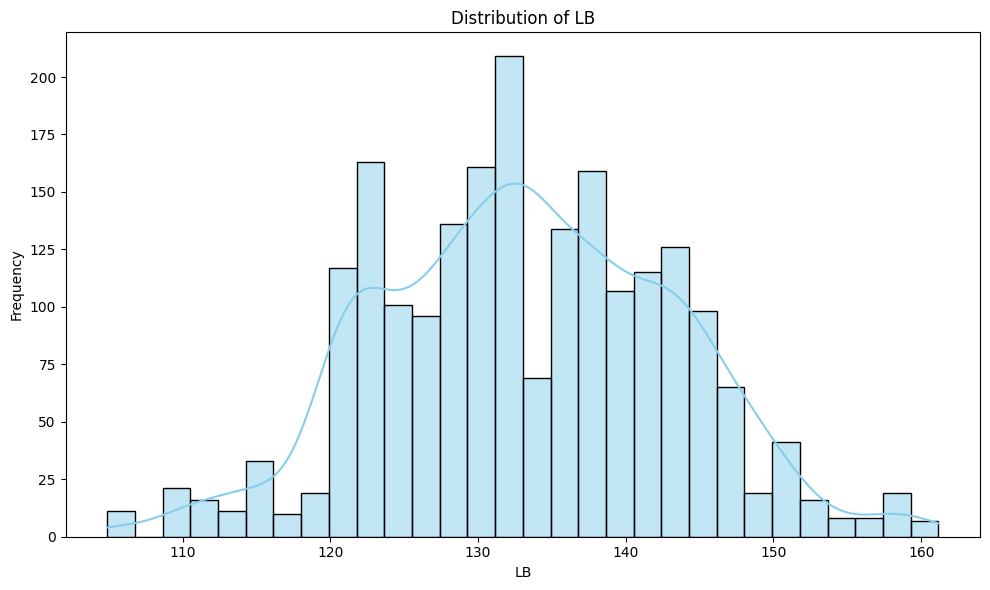

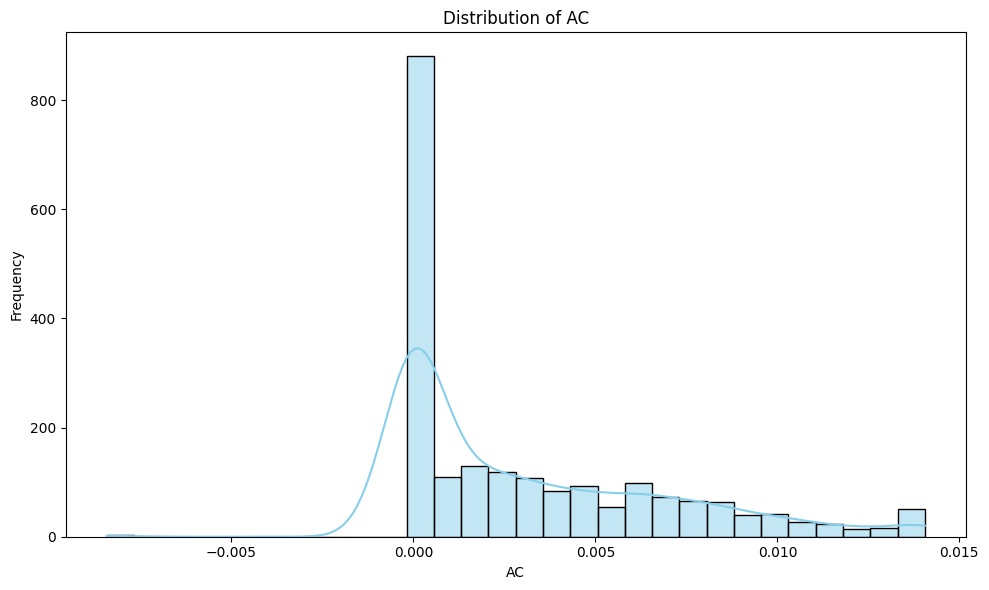

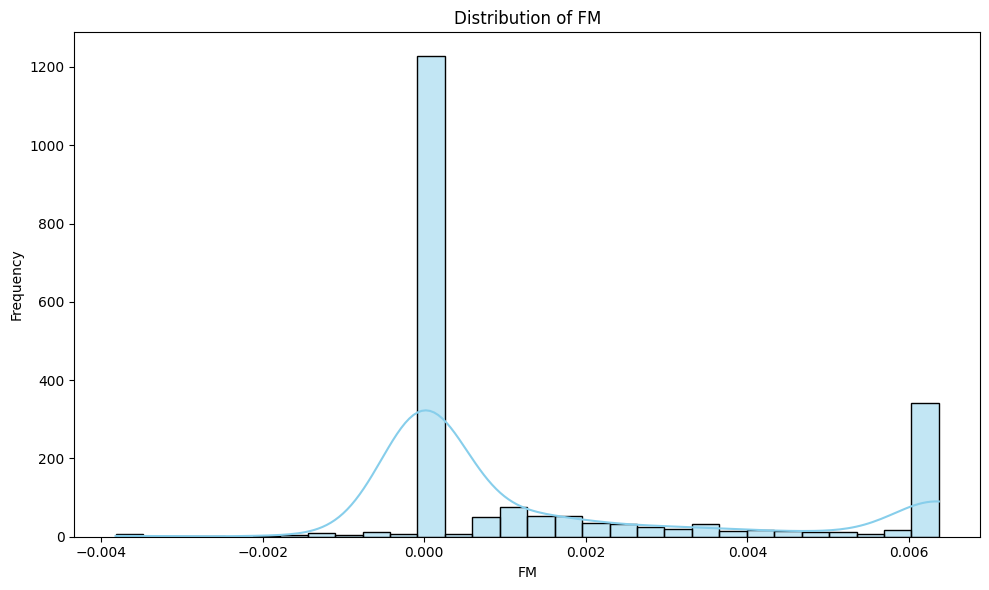

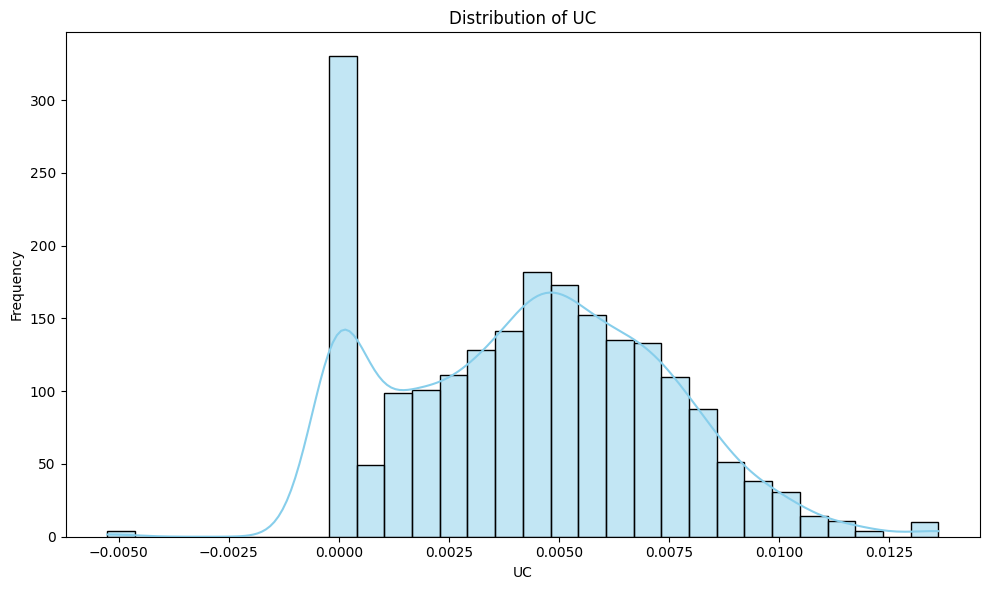

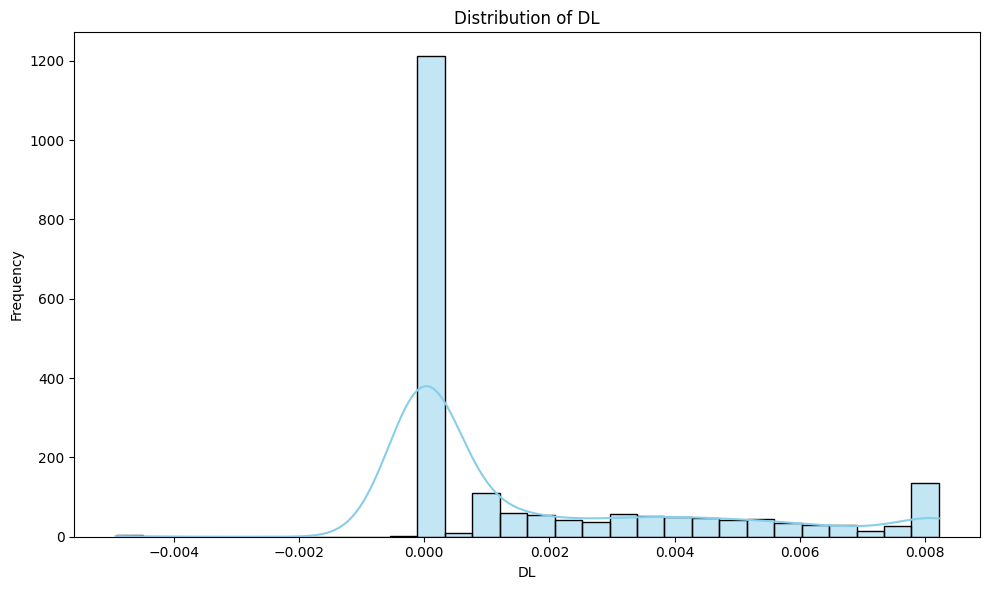

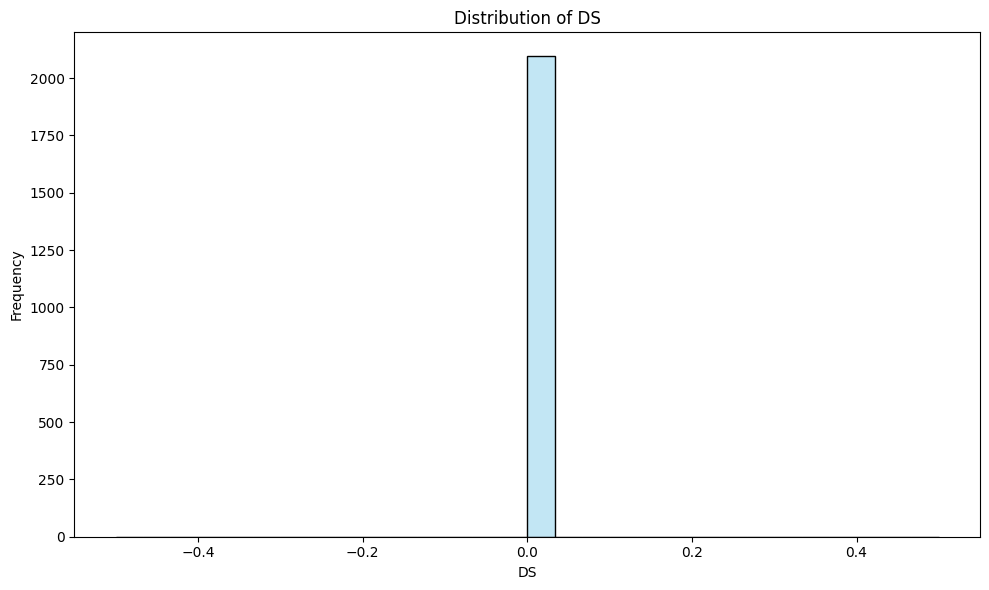

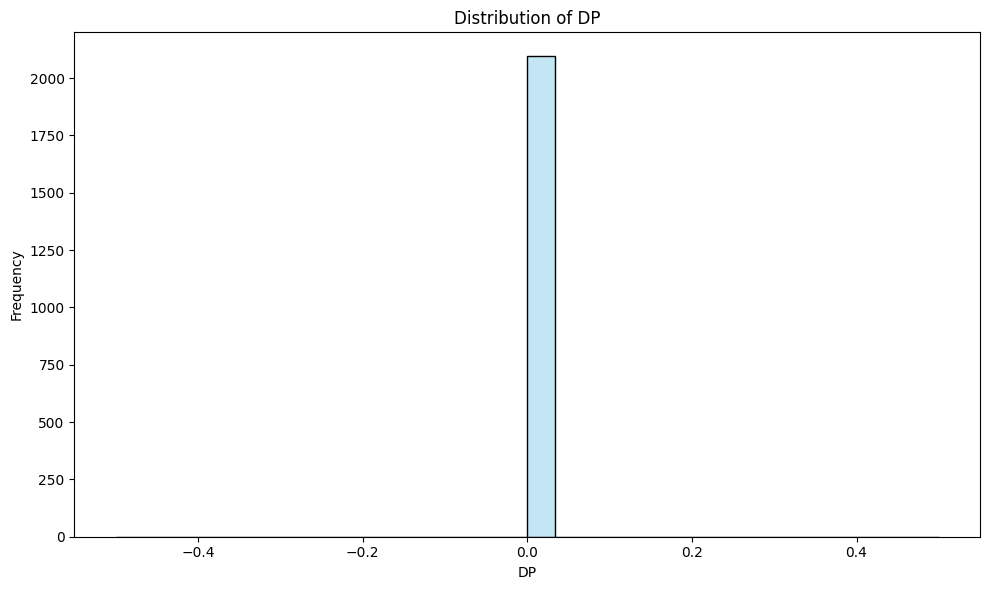

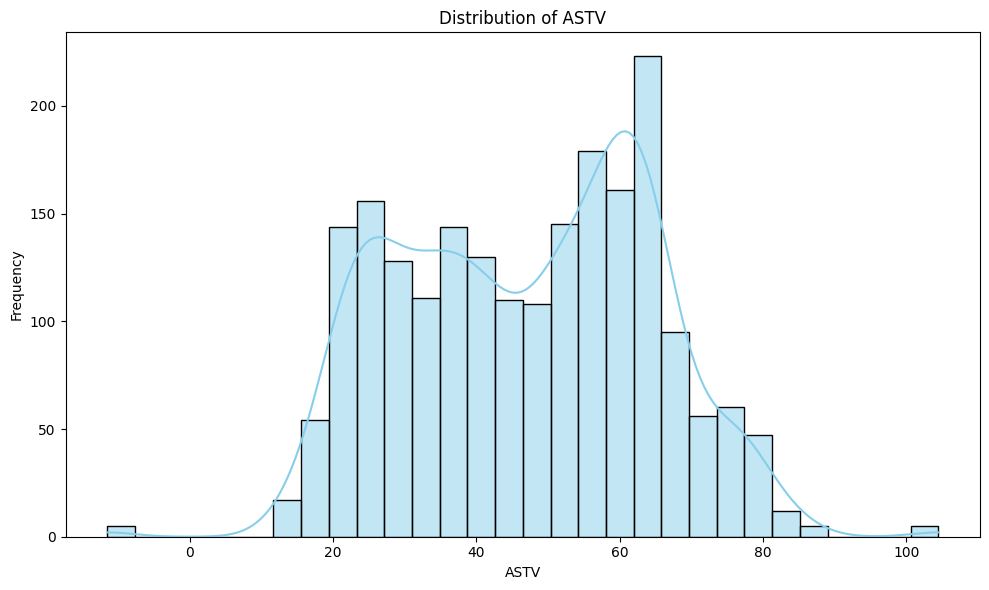

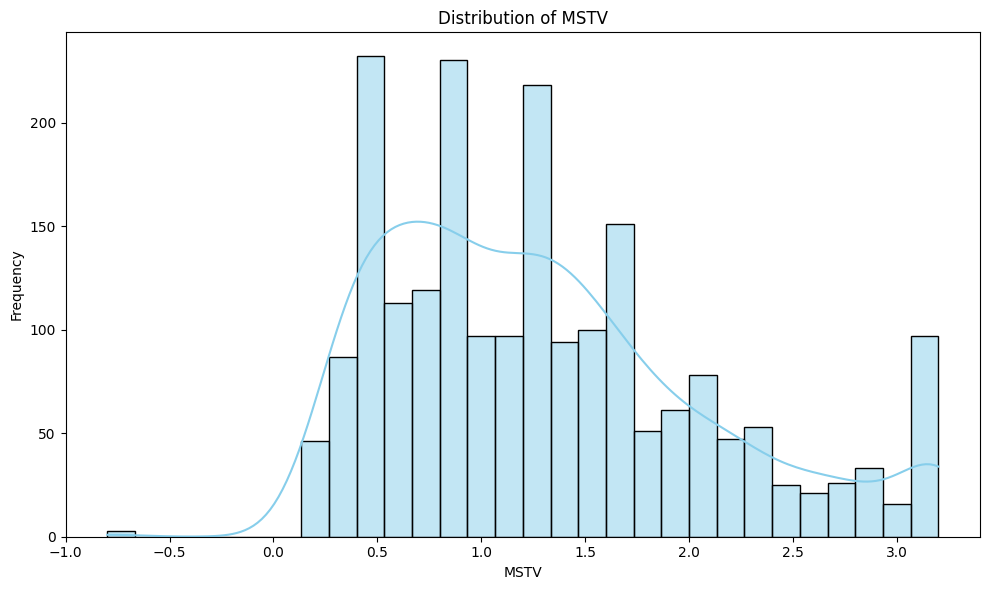

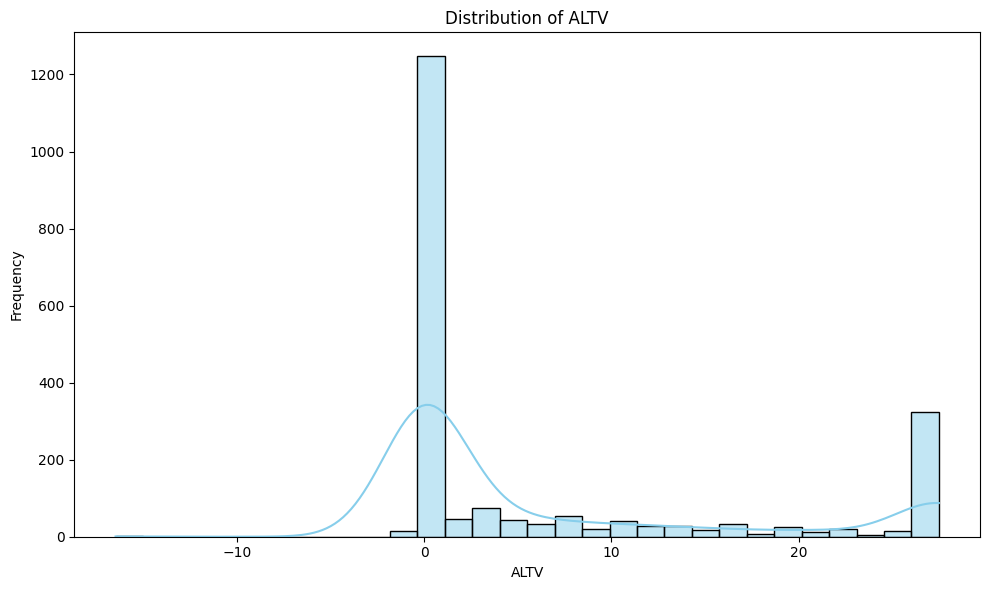

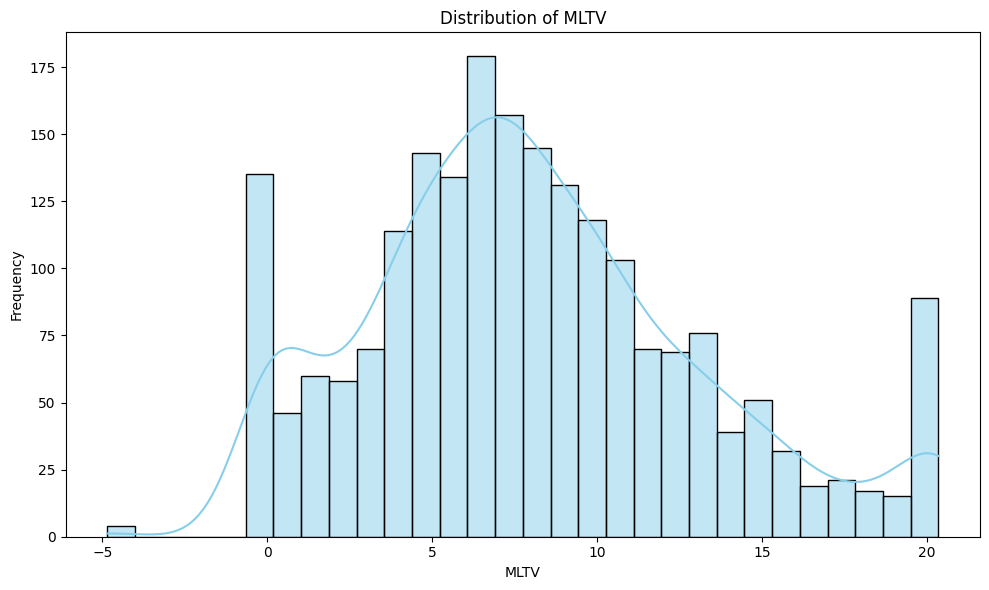

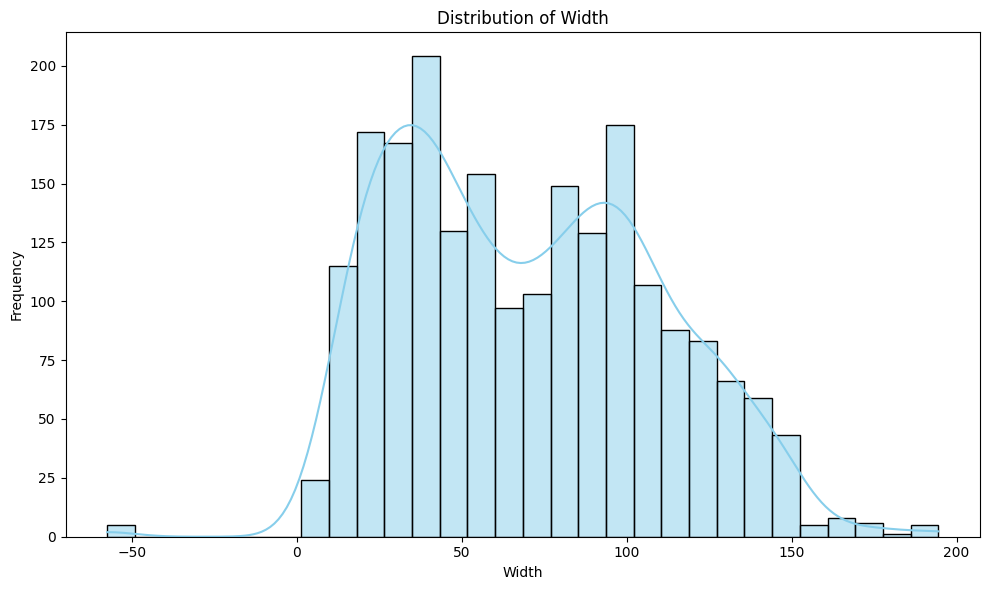

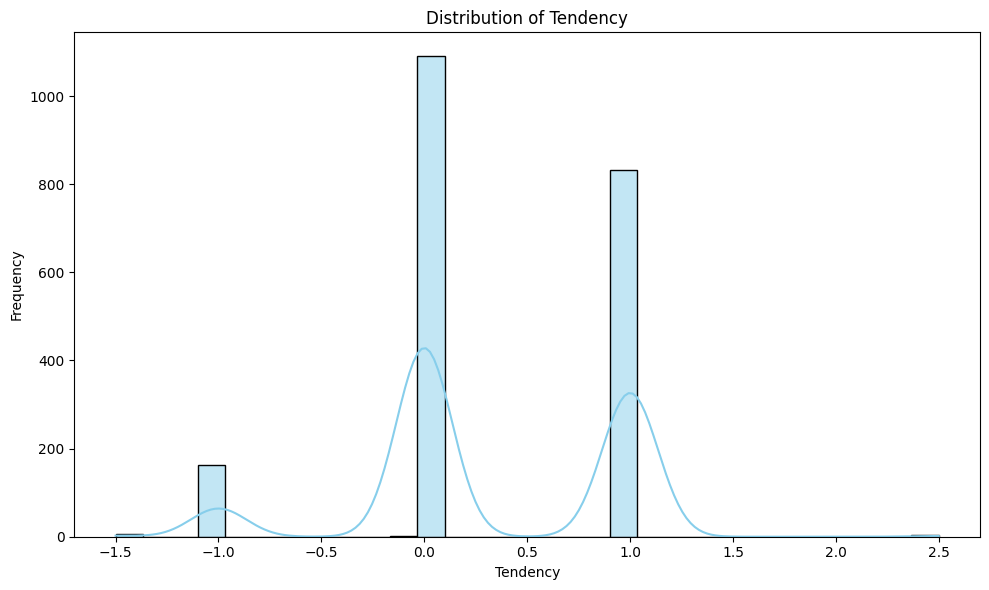

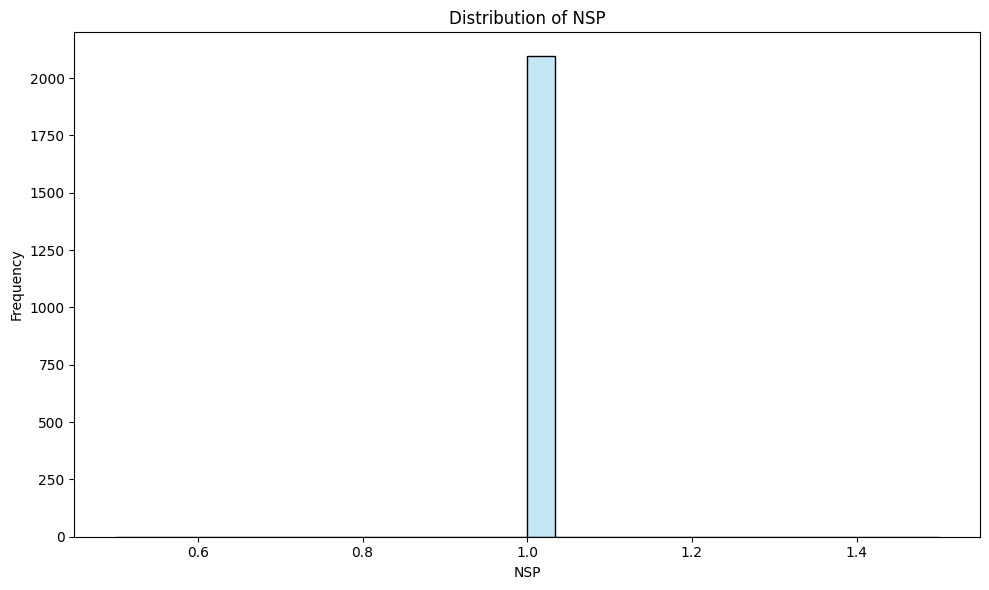

In [51]:
#Histogram
import matplotlib.pyplot as plt
import seaborn as sns

for column in data_new.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data_new[column], bins=30, kde=True, color='skyblue', edgecolor='black')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

In [52]:
#NO Pie Chart or Bar grapg because we have categorial variable.

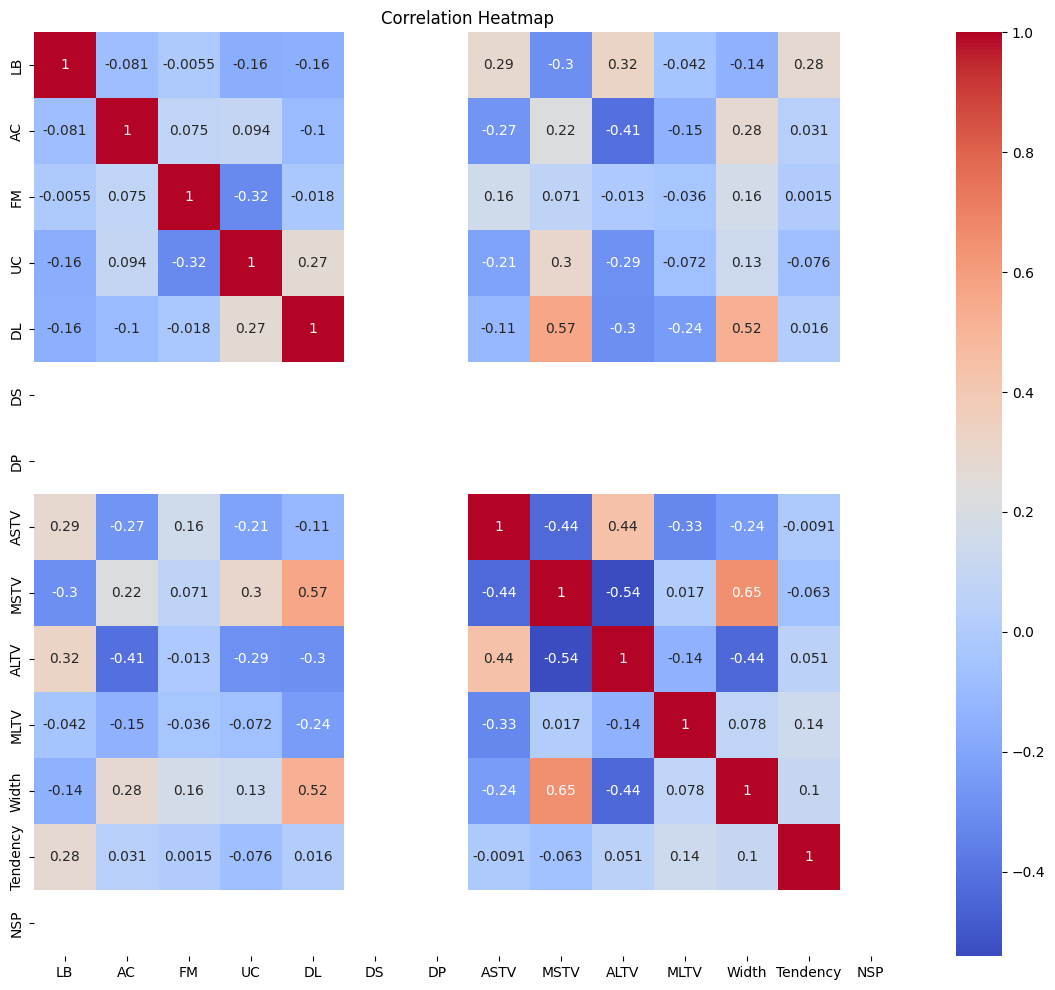

In [53]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(data_new.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**No Correlation of NSP,DP,DS with other.**

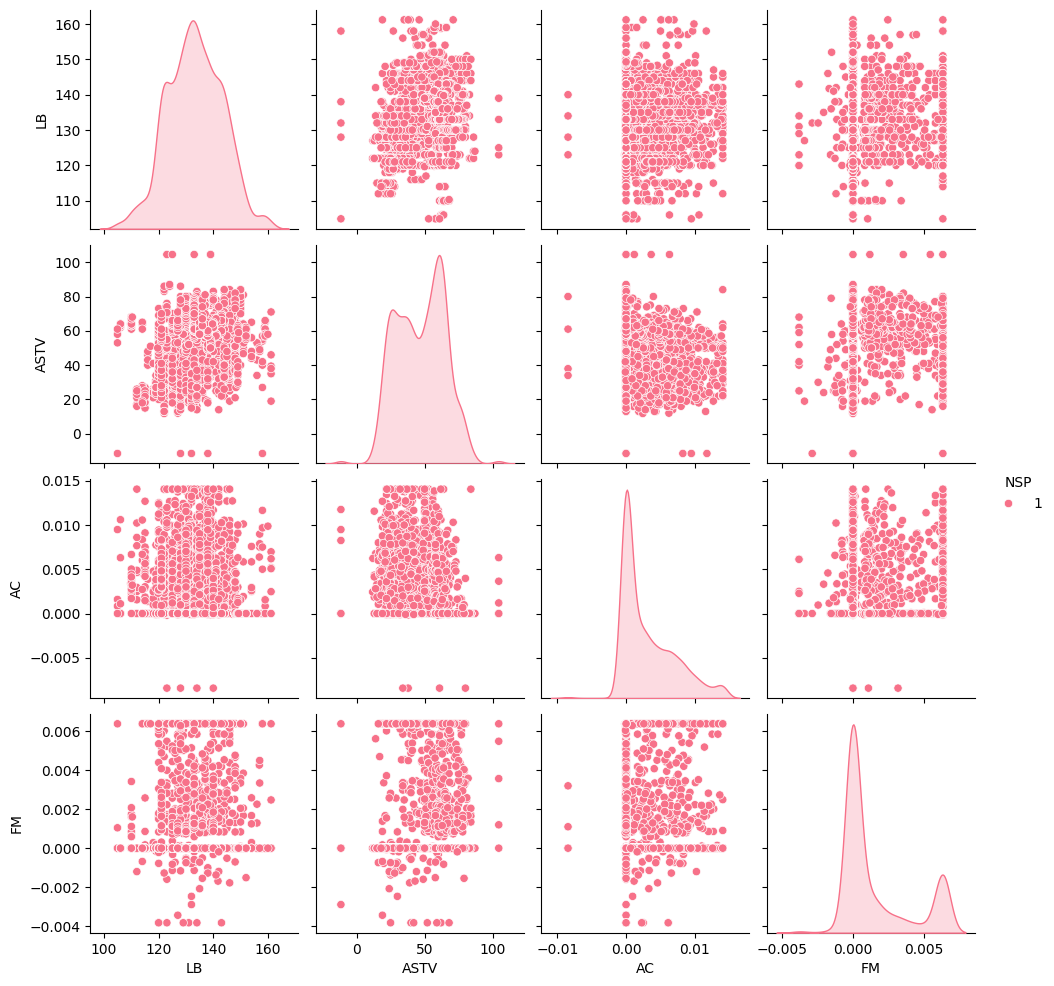

In [54]:
# Pairplot for advanced pattern recognition
sns.pairplot(data_new[['LB', 'ASTV', 'AC', 'FM', 'NSP']], hue='NSP', palette='husl')
plt.show()

4.	Pattern Recognition and Insights:

●	Identify any correlations between variables and discuss their potential implications.

●	Look for trends or patterns over time if temporal data is available.


**Based on the exploratory analysis of the provided csv data:**

**The "Accelerations" Factor:** The data dictionary suggests AC (Accelerations) represents fetal well-being. In the dataset, rows with AC values > 0 are overwhelmingly associated with NSP Class 1. Conversely, records with AC = 0 often coincide with higher ASTV and NSP Class 2 or 3.

**Variability indicates Distress:** High values in ASTV (e.g., values > 60)  show a strong pattern matching with NSP classes 2 and 3. This confirms that abnormal variability is a key predictor for the classifier.

5.	Conclusion:

●	Summarize the key insights and patterns discovered through your exploratory analysis.

●	Discuss how these findings could impact decision-making or further analyses.


**Summary of Key Insights**

**Predictive Power:** ASTV (Abnormal Short Term Variability) and AC (Accelerations) appear to be the strongest differentiators between Normal (1) and Pathologic (3) fetuses.

**Data Integrity:** The provided dataset is noisy. It contains formatting errors, high-precision floating-point noise, and impossible negative physical measurements. Significant pre-processing is required before this data can be used for machine learning models.

**Class Imbalance:** The dataset is heavily skewed toward Normal cases (NSP=1), which could bias future predictive models if not addressed via resampling techniques.

**Recommendations**


**Feature Engineering:** Consider creating a "Total Decelerations" feature by summing DL, DS, and DP to capture overall distress signals.

**Next Steps:** Proceed to predictive modeling using a Random Forest or Gradient Boosting classifier, as the non-linear relationships between ASTV, LB, and NSP are distinct.